In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'


# This is required to run multiple processes with JAX.
from multiprocessing import set_start_method
set_start_method('forkserver', force=True)

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import equinox as eqx

from tqdm import tqdm
from pathlib import Path

# print(jax.devices())
# jax.config.update("jax_debug_nans", True)

from config import Config
import data, train, evaluate

In [3]:
run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/kge/era5_zstd_20251216_200619")
trainer = train.Trainer.load_last_checkpoint(run_dir)
cfg = trainer.cfg.model_copy()

results = pd.read_parquet(run_dir / 'results' / 'test_results.parquet')

Loading model from /nas/cee-water/cjgleason/ted/swot-ml/runs/kge/era5_zstd_20251216_200619/checkpoints/step_009000
Model contains 379,361 parameters
Loading trainer from checkpoint step_009000
Logging at /nas/cee-water/cjgleason/ted/swot-ml/runs/kge/era5_zstd_20251216_200619


In [10]:
trainer.model.head['discharge'].mlp.layers[0].weight

Array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [4]:
# save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
# metadata_dir = save_dir / "metadata"
# subbasins = gpd.read_parquet(metadata_dir / 'subbasins.parquet')
subbasins = gpd.read_parquet("/nas/cee-water/cjgleason/ted/graph_delineator/data/clamped_manual_matchups_500/subbasins/USGS-07374000_subbasins.parquet")
subbasins = subbasins.set_index('id')
subbasins.index = subbasins.index.astype(str)
subbasins.geometry = subbasins.geometry.centroid

subbasins

/tmp/ipykernel_1326668/3801433619.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subbasins.geometry = subbasins.geometry.centroid


,geometry,area_km2,uparea_km2,node_type,is_gauge,nextdown
id,,,,,,
74028485,POINT (-94.64153 42.71431),173.772278,1.737723e+02,original,False,74023879
74021683,POINT (-103.3237 44.16328),31.952856,3.195286e+01,original,False,74017731
74043667,POINT (-100.31559 39.46983),70.224778,7.022478e+01,original,False,74039036
74043525,POINT (-100.49939 39.41684),225.434216,2.254342e+02,original,False,74039036
74043323,POINT (-101.17129 39.37045),169.761879,1.697619e+02,original,False,74039673
...,...,...,...,...,...,...
USGS-07292500,POINT (-90.97146 31.32657),483.330429,2.039318e+03,gauge,True,74070126
USGS-07290650,POINT (-90.63394 32.06804),463.665634,1.697335e+03,gauge,True,74069837
USGS-07291000,POINT (-90.71194 31.65082),467.570773,4.675708e+02,gauge,True,74070222


In [8]:
cfg.quiet = False
mgr = data.DynamicCacheManager(cfg)
cache_dir = mgr.create_cache('train')
dataset = data.CachedBasinGraphDataset(cfg, cache_dir, 'train')

Caches will be stored at: /scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/_cache/337de864b02d08e5
Calculating training statistics for encoding and normalization...
✅ All caches created and indexed.
Calculating training statistics for encoding and normalization...
Loading basin graphs...Done!
Loading optimized indices for train...Done!


In [9]:
cfg.target_nodes_per_batch = 8144
cfg.num_workers = 0
dataloader = data.CachedBasinGraphDataLoader(cfg, dataset)

for basin, subbasin, date, batch in dataloader:
    break

Dataloader using 0 parallel CPU worker(s).


In [10]:
batch.dynamic['swot-river'].shape

(90, 8144, 32)

In [11]:
key = jax.random.PRNGKey(0)

model = eqx.tree_at(
    lambda m: m.return_weights,
    trainer.model,
    replace=True,
)
model = eqx.nn.inference_mode(model, True)

result = model(batch, key)
pred, weights = result

# for basin, subbasin, date, batch in dataloader:
#     break

In [12]:
weights.keys()

dict_keys(['spatial', 'fusion'])

In [26]:
weights['spatial'].keys()

dict_keys(['downstream_weight', 'r_gate', 'upstream_gate', 'z_gate'])

In [34]:
timestep = -1
head = 0
k_hop = 0
    
edge_weights = weights['spatial']['downstream_weight'][timestep, :, head, k_hop]

# edge_weights = weights['graph']['downstream_weights'][timestep, ...]
# edge_weights = edge_weights.mean(axis=(-2,-1))

z_gate = weights['spatial']['z_gate'][timestep,...].mean(axis=-1)

edge_weights = edge_weights# * z_gate

edge_weights.shape

(8144,)

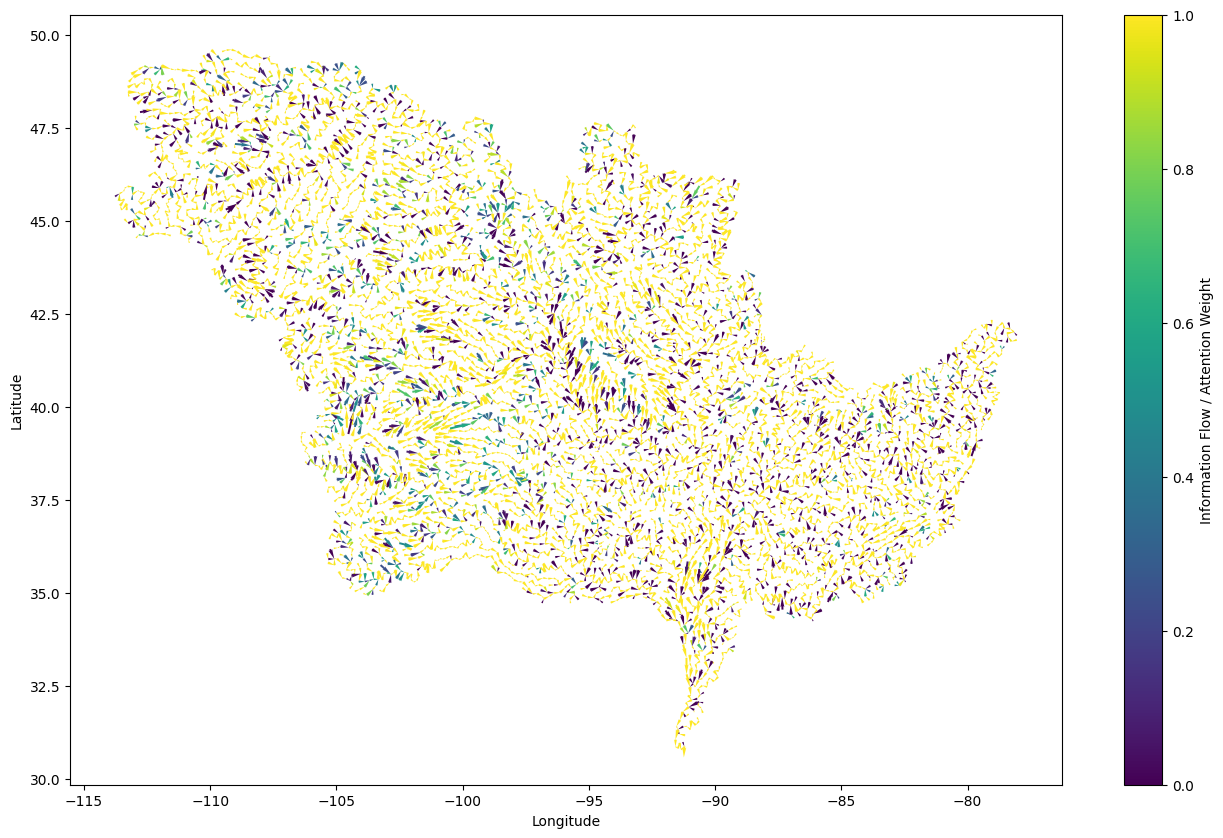

In [35]:
# Extract centroids to a numpy array for speed
# We build a dict first: {site_id: (x, y)}
centroids = subbasins.geometry
geo_lookup = {
    site_id: (pt.x, pt.y) 
    for site_id, pt in zip(centroids.index, centroids)
}

# --- Step 2: Map Batch Nodes to Coordinates ---
# Determine number of real (non-padded) nodes
num_real_nodes = int(np.sum(batch.node_mask))

# Create an array of (x, y) coordinates aligned with the Batch Node Indices
# Shape: (num_real_nodes, 2)
batch_node_coords = np.zeros((num_real_nodes, 2))

for i in range(num_real_nodes):
    site_id = subbasin[i]
    batch_node_coords[i] = geo_lookup[site_id]

# --- Step 3: Extract Real Edges ---
# The batch edges are padded. We only want the real ones.
edge_mask = batch.edge_mask.astype(bool)

# shape: (2, num_real_edges)
real_edges = batch.graph_edges[:, edge_mask]

src_indices = real_edges[0]
dst_indices = real_edges[1]

# --- Step 4: Calculate Quiver Vectors ---
# Look up coordinates for every edge's source and destination
# shape: (num_real_edges, 2)
start_coords = batch_node_coords[src_indices]
end_coords = batch_node_coords[dst_indices]

# Calculate vector components (U, V)
vectors = end_coords - start_coords
U = vectors[:, 0]
V = vectors[:, 1]

# Origin points for the arrows (X, Y)
X = start_coords[:, 0]
Y = start_coords[:, 1]

# Extract only real edge weights
C = edge_weights[edge_mask]

# --- Step 6: Plotting ---
fig, ax = plt.subplots(figsize=(16, 10))

# Create the Quiver Plot
# X, Y: Arrow origins
# U, V: Arrow components
# C: Color array (mapped to colormap)
q = ax.quiver(
    X, Y, U, V, C,
    cmap='viridis',
    scale=1, 
    scale_units='xy',
    angles='xy',
    width=0.002,
    headwidth=2
)

plt.colorbar(q, label="Information Flow / Attention Weight")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [111]:
C.shape

(8142,)

In [18]:
weights['fusion'].keys()

dict_keys(['gate', 'valid_obs', 'weights'])

In [20]:
weights['fusion']['gate'].shape

(90, 8144, 64)